In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt
from rich.console import Console

from libdet import Hamiltonian
from detnqs.model import Backflow, RBackflow, RBM
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import psr, minsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [2]:
mol = gto.M(
    atom=
    '''
    N   0.53920000,  0.00000000,  0.0000000
    N   -0.539200000,  0.00000000,  0.0000000
    ''',
    # atom=
    # '''
    # O   0.00000000,  0.00000000,  0.00000000
    # H   0.75700000,  0.00000000,  0.58590000
    # H  -0.75700000,  0.00000000,  0.58590000
    # ''',
    # atom=
    # '''
    # Li   3.732, 0.25, 0.0
    # Li   2.0, 0.25, 0.0
    # O  2.866, -0.25, 0.0
    # ''',
    basis="sto-3g",
    unit="Angstrom",
    spin=0,
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -109.099941428008 # N2_631g
# e_fci = -87.892693 # Li2O_sto3g
# e_fci = -76.243769 # H2O_ccpvdz

solver = fci.direct_spin0.FCI(mol)
solver.nroots = 2
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
s2, mult = fci.spin_op.spin_square(ci[0], norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -107.488973088654
FCI energy : -107.640233152151
S^2  : 0.000000


In [4]:
model = RBackflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))
# model = RBM(norb=norb, alpha=1)

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=32,
    proposal="ham",
    proposal_eps=1e-3,
    blur=0.5,
    blur_eps=1e-3
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
    eloc_eps1=1e-3,
    eloc_eps2=1e-6,
    eloc_sample=1024
)

steps = 1000
optimizer = optax.chain(
    psr(shift=1e-3),
    optax.scale(-5e-2)
)

--------------------------------------------------------------------------------------------------------
Step        Energy         |E-E0|       Var        Acc      ESS      N_u      N_f     alpha    SR cond  
--------------------------------------------------------------------------------------------------------


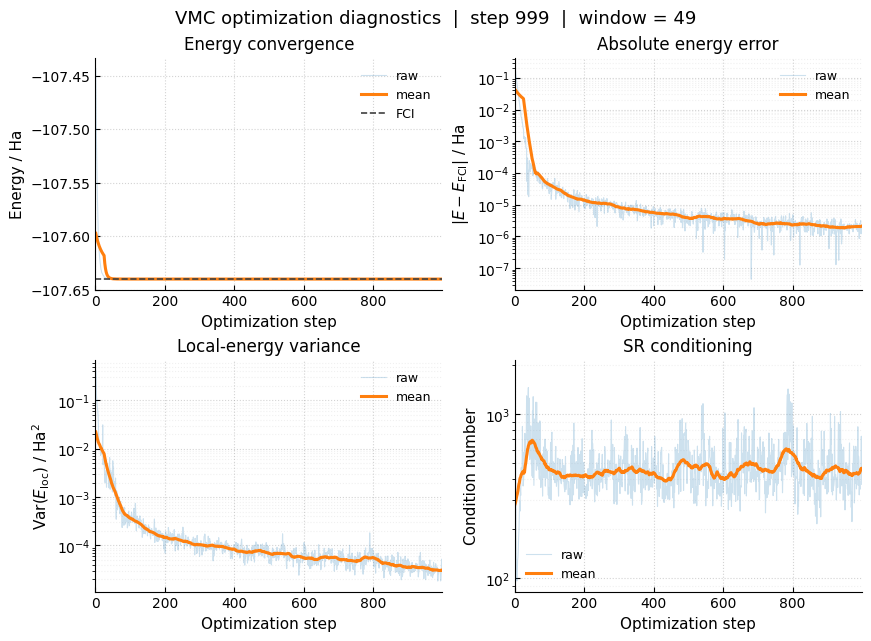

  0     -107.49552785     1.45e-01    3.12e-01    0.5%     50.2%     116     2235     1.000    3.56e+04 
 10     -107.61037337     2.99e-02    1.43e-02    27.1%    18.2%     398     3589     0.608    1.47e+02 
 20     -107.63512039     5.11e-03    8.63e-03    35.4%    8.8%      469     3598     0.695    4.44e+02 
 30     -107.63935239     8.81e-04    2.84e-03    34.3%    7.1%      471     3606     0.784    6.55e+02 
 40     -107.64021532     1.78e-05    4.10e-03    30.8%    7.5%      462     3584     0.847    6.20e+02 
 50     -107.64010055     1.33e-04    5.64e-03    30.7%    9.8%      440     3588     0.878    4.18e+02 
 60     -107.64010154     1.32e-04    3.49e-04    30.8%    10.7%     412     3545     0.874    1.18e+03 
 70     -107.64018352     4.96e-05    4.51e-04    29.1%    10.6%     411     3578     0.858    4.11e+02 
 80     -107.64020187     3.13e-05    3.76e-04    31.2%    11.0%     438     3586     0.836    3.17e+02 
 90     -107.64018395     4.92e-05    3.46e-04    32.9%

In [5]:
from collections import defaultdict
from IPython.display import display

METRICS = {
    "step":     ("Step",    "d",    5),
    "energy":   ("Energy",  ".8f", 16),
    "error":    ("|E-E0|", ".2e", 10),
    "variance": ("Var",    ".2e", 10),
    "accept":   ("Acc",    ".1%",  7),
    "ess_frac": ("ESS",    ".1%",  7),
    "n_unique": ("N_u",    ".0f",  7),
    "n_eval":   ("N_f",    ".0f",  7),
    "alpha":    ("alpha",  ".3f",  7),
    "sr_cond":  ("SR cond", ".2e", 10),
}

header = "  ".join(f"{label:^{width}}" for label, _, width in METRICS.values())
line = "-" * len(header)
print(line, header, line, sep="\n")


# ----------------------------------------------------------------------
# Online figure
# ----------------------------------------------------------------------
plot_every = 10
max_window = 50

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.3), constrained_layout=True)
axes = axes.ravel()

energy_raw, = axes[0].plot([], [], lw=0.8, alpha=0.22, label="raw")
energy_avg, = axes[0].plot([], [], lw=2.2, label="mean")
axes[0].axhline(e_fci, ls="--", lw=1.2, color="0.25", label="FCI")
axes[0].set(title="Energy convergence", xlabel="Optimization step", ylabel="Energy / Ha")

error_raw, = axes[1].plot([], [], lw=0.8, alpha=0.22, label="raw")
error_avg, = axes[1].plot([], [], lw=2.2, label="mean")
axes[1].set_yscale("log")
axes[1].set(title="Absolute energy error", xlabel="Optimization step",
            ylabel=r"$|E - E_\mathrm{FCI}|$ / Ha")

var_raw, = axes[2].plot([], [], lw=0.8, alpha=0.22, label="raw")
var_avg, = axes[2].plot([], [], lw=2.2, label="mean")
axes[2].set_yscale("log")
axes[2].set(title="Local-energy variance", xlabel="Optimization step",
            ylabel=r"$\mathrm{Var}(E_\mathrm{loc})$ / Ha$^2$")

cond_raw, = axes[3].plot([], [], lw=0.8, alpha=0.22, label="raw")
cond_avg, = axes[3].plot([], [], lw=2.2, label="mean")
axes[3].set_yscale("log")
axes[3].set(title="SR conditioning", xlabel="Optimization step", ylabel="Condition number")

for ax in axes:
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, which="major", ls=":", alpha=0.55)
    ax.grid(True, which="minor", ls=":", alpha=0.18)
    ax.tick_params(labelsize=10, direction="in")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.title.set_size(12)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)

fig.suptitle("VMC optimization diagnostics", fontsize=13)

display_handle = display(fig, display_id=True)
plt.close(fig)


# ----------------------------------------------------------------------
# VMC optimization
# ----------------------------------------------------------------------
vmc = VMC.init(state, optimizer)
history = []
total_times = defaultdict(float)

for step in range(steps):
    stats = dict(vmc.step())
    stats["step"] = step
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(stats)

    for key, value in stats.items():
        if key.startswith("time_"):
            total_times[key.removeprefix("time_")] += float(value)

    if step % 10 == 0 or step == steps - 1:
        row = []
        for key, (_, fmt, width) in METRICS.items():
            value = stats.get(key, np.nan)
            text = f"{int(value):{fmt}}" if fmt == "d" else f"{float(value):{fmt}}"
            row.append(f"{text:^{width}}")
        print("  ".join(row))

    if step % plot_every == 0 or step == steps - 1:
        hist = {
            key: np.asarray([record.get(key, np.nan) for record in history], dtype=float)
            for key in METRICS
        }

        mask = hist["step"] > 0
        x = hist["step"][mask]

        if len(x):
            e = hist["energy"][mask]
            err = np.clip(hist["error"][mask], 1e-16, None)
            var = np.where(hist["variance"][mask] > 0, hist["variance"][mask], np.nan)
            cond = np.where(hist["sr_cond"][mask] > 0, hist["sr_cond"][mask], np.nan)

            window = min(max_window, max(5, 2 * (len(x) // 40) + 1))
            kernel = np.ones(window)

            valid = np.isfinite(e)
            e_mean = np.convolve(np.where(valid, e, 0.0), kernel, mode="same")
            e_norm = np.convolve(valid.astype(float), kernel, mode="same")
            e_mean = e_mean / np.maximum(e_norm, 1.0)
            e_mean[e_norm == 0] = np.nan
            err_mean = np.clip(np.abs(e_mean - e_fci), 1e-16, None)

            log_var = np.log(var)
            valid = np.isfinite(log_var)
            var_mean = np.convolve(np.where(valid, log_var, 0.0), kernel, mode="same")
            var_norm = np.convolve(valid.astype(float), kernel, mode="same")
            var_mean = np.exp(var_mean / np.maximum(var_norm, 1.0))
            var_mean[var_norm == 0] = np.nan

            log_cond = np.log(cond)
            valid = np.isfinite(log_cond)
            cond_mean = np.convolve(np.where(valid, log_cond, 0.0), kernel, mode="same")
            cond_norm = np.convolve(valid.astype(float), kernel, mode="same")
            cond_mean = np.exp(cond_mean / np.maximum(cond_norm, 1.0))
            cond_mean[cond_norm == 0] = np.nan

            energy_raw.set_data(x, e)
            energy_avg.set_data(x, e_mean)

            error_raw.set_data(x, err)
            error_avg.set_data(x, err_mean)

            var_raw.set_data(x, var)
            var_avg.set_data(x, var_mean)

            cond_raw.set_data(x, cond)
            cond_avg.set_data(x, cond_mean)

            for ax in axes:
                ax.relim()
                ax.autoscale_view()
                ax.set_xlim(0, max(steps - 1, 1))

            fig.suptitle(
                f"VMC optimization diagnostics  |  step {step}  |  window = {window}",
                fontsize=13,
            )
            display_handle.update(fig)

print(line)

if total_times:
    times = sorted(
        (item for item in total_times.items() if item[0] != "total"),
        key=lambda item: item[1],
        reverse=True,
    )
    print("Time:", "  ".join(f"{key}={value:.2f}s" for key, value in times))
    print(line)